In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split



In [114]:
books = pd.read_csv('../data/books_data_2.csv')
books.head()


,kind,title,category,publishDate,publishYear,authorCount,pageCount,maturityRating,saleability,publisher,retailPrice,retailCurrency
0,books#volume,Persuasion,Fiction,2023-03-02,2023,1,276.0,NOT_MATURE,FOR_SALE,neobooks,1.49,GBP
1,books#volume,The Face of Another,Fiction,1992,1992,1,260.0,NOT_MATURE,NOT_FOR_SALE,Kodansha,NaN,NaN
2,books#volume,The Street of Crocodiles,Fiction,2025-03-19T00:00:00Z,2025,1,136.0,NOT_MATURE,NOT_FOR_SALE,Rare Treasure Editions,NaN,NaN
3,books#volume,The Sign of the Four Illustrated,Fiction,2021-05-02,2021,1,156.0,NOT_MATURE,NOT_FOR_SALE,NaN,NaN,NaN
4,books#volume,Generations of Winter,Fiction,1994,1994,1,616.0,NOT_MATURE,NOT_FOR_SALE,Random House (NY),NaN,NaN


In [115]:
books_noduplicates = books.drop_duplicates(subset=["title"])
books_noduplicates.dropna(subset=["saleability"])
books_noduplicates.shape

(5104, 12)

In [5]:
books_noduplicates.info()

<class 'pandas.DataFrame'>
Index: 5104 entries, 0 to 5840
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   kind            5104 non-null   str    
 1   title           5104 non-null   str    
 2   category        5104 non-null   str    
 3   publishDate     5081 non-null   str    
 4   publishYear     5081 non-null   str    
 5   authorCount     5104 non-null   int64  
 6   pageCount       4995 non-null   float64
 7   maturityRating  5104 non-null   str    
 8   saleability     5104 non-null   str    
 9   publisher       3436 non-null   str    
 10  retailPrice     506 non-null    float64
 11  retailCurrency  506 non-null    str    
dtypes: float64(2), int64(1), str(9)
memory usage: 518.4 KB


In [54]:
books_noduplicates.describe(include=['object','category', 'str'])

,kind,title,category,publishDate,publishYear,maturityRating,saleability,publisher,retailCurrency
count,5104,5104,5104,5081,5081,5104,5104,3436,506
unique,1,5104,40,2038,197,2,4,1169,1
top,books#volume,Persuasion,Science,2002,2017,NOT_MATURE,NOT_FOR_SALE,Routledge,GBP
freq,5104,1,159,91,177,5049,4454,124,506


In [55]:
books_noduplicates.describe()

,authorCount,pageCount,retailPrice
count,5104.000000,4995.000000,506.000000
mean,1.267437,333.873073,30.686719
std,0.706060,334.693454,74.203020
min,0.000000,0.000000,0.000000
25%,1.000000,170.500000,6.840000
50%,1.000000,286.000000,14.990000
75%,1.000000,424.000000,35.590000
max,16.000000,7800.000000,1462.750000


In [53]:
books_noduplicates["saleability"].value_counts()

saleability
NOT_FOR_SALE           4454
FOR_SALE                458
FREE                    144
FOR_SALE_AND_RENTAL      48
Name: count, dtype: int64

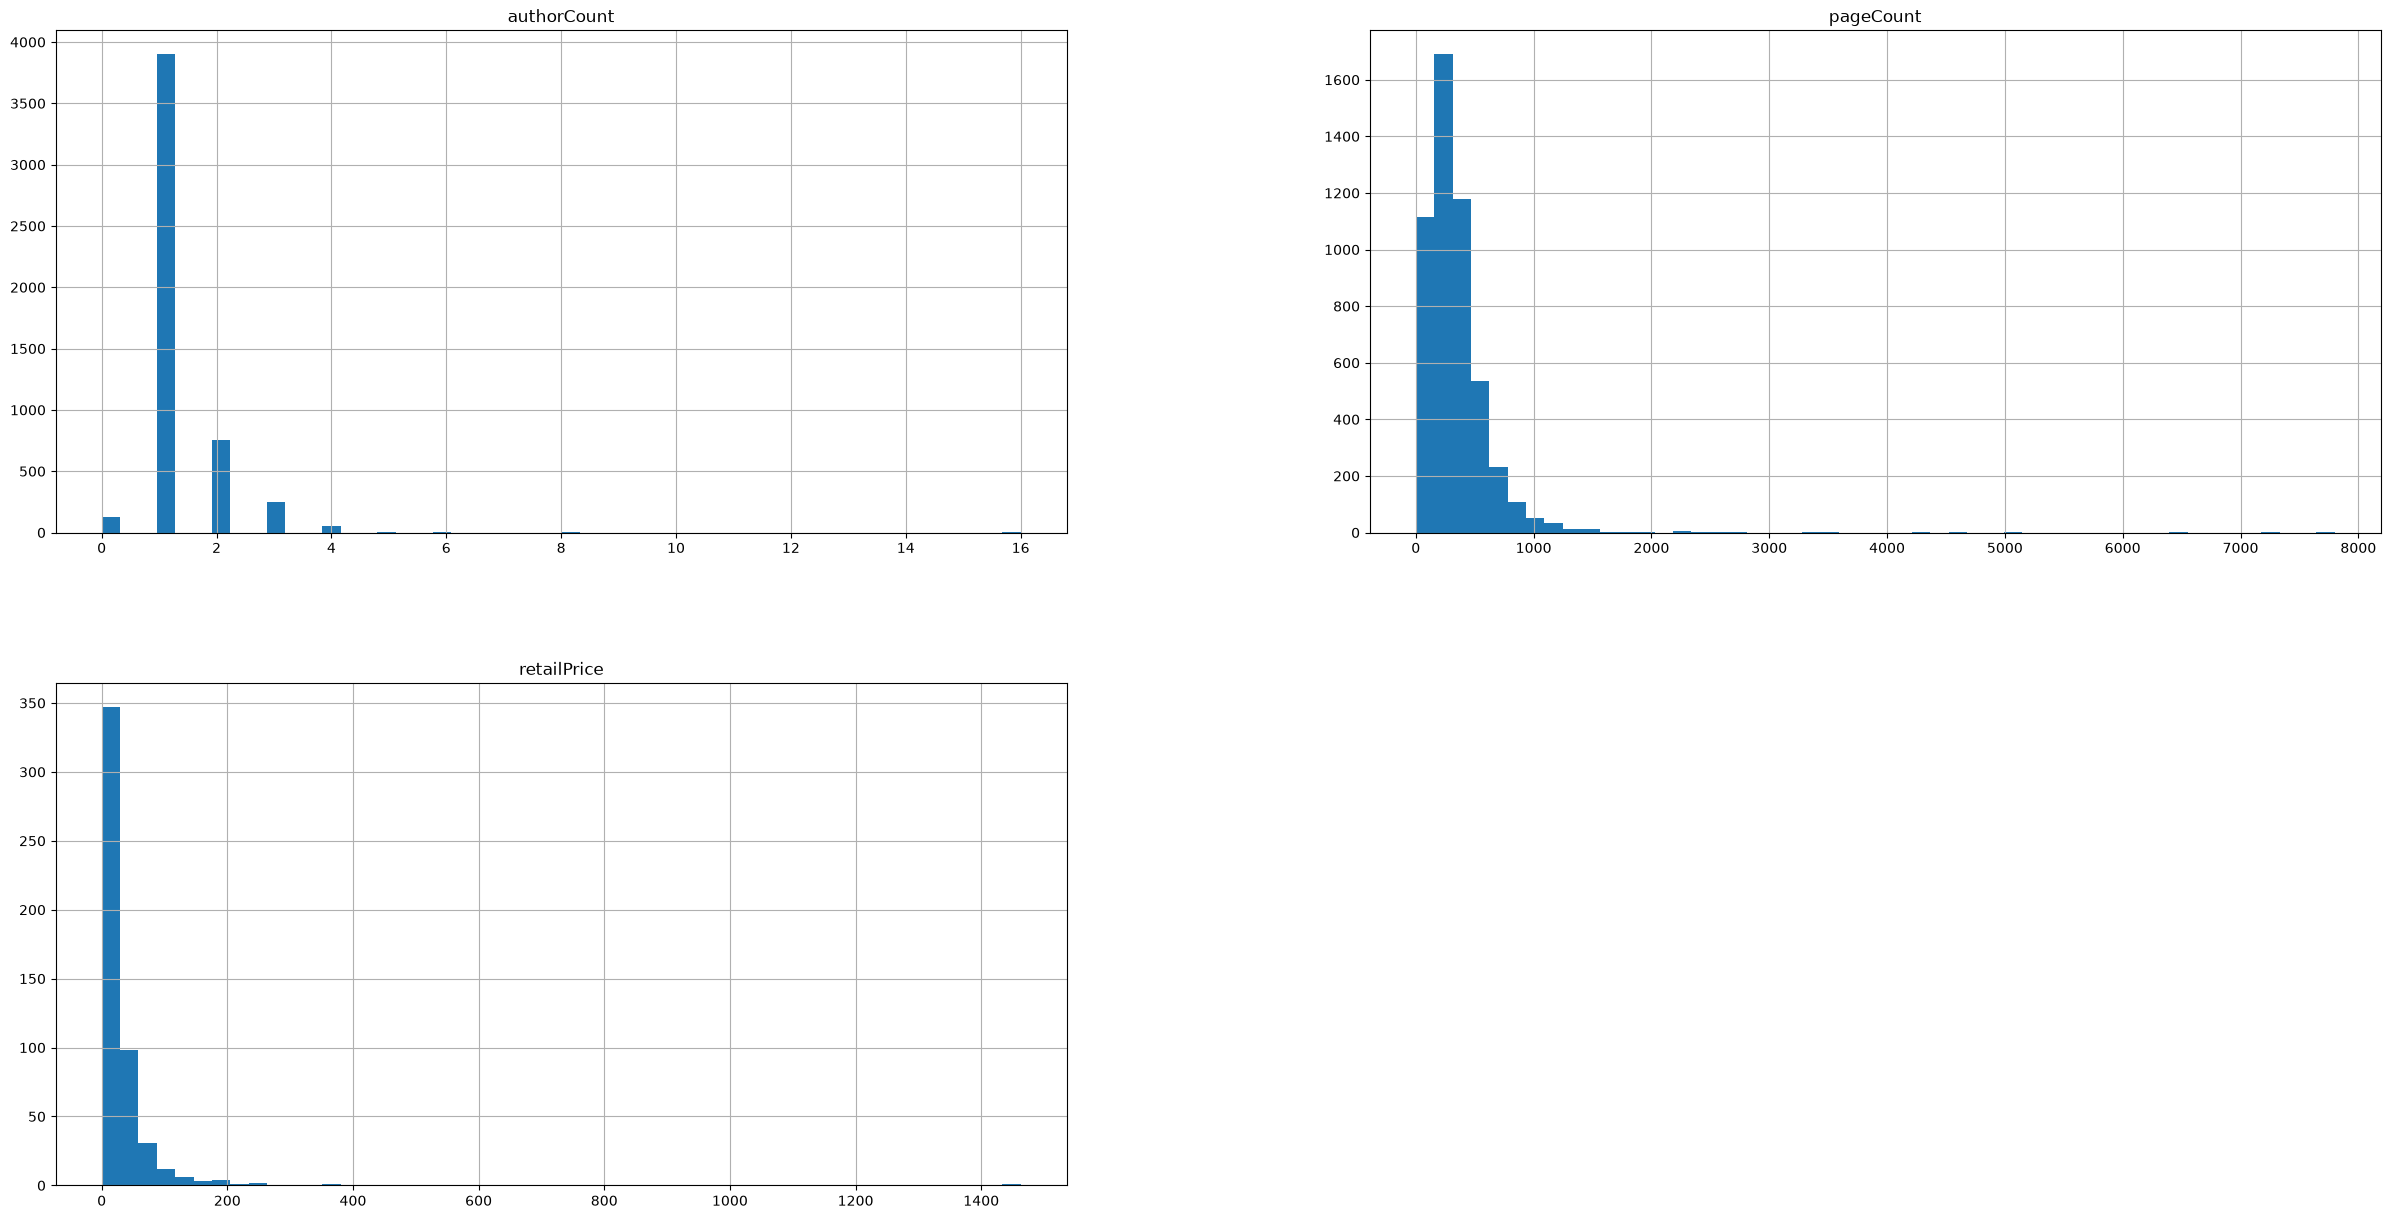

In [24]:


books_noduplicates.hist(bins=50, figsize=(30,15))
plt.savefig("../images/histogram_plots.png")
plt.show()

In [117]:
books_noduplicates["publishYear"] = pd.to_numeric(
    books_noduplicates["publishYear"], 
    errors="coerce"
)

In [54]:

train_df, test_df = train_test_split(books_noduplicates, test_size=0.2, stratify= books_noduplicates["saleability"], random_state=42)


X_train = (
    train_df
    .drop(columns=["retailPrice", "retailCurrency", "publishDate", "kind", "saleability"])
    .dropna(subset=["publishYear"])
)
y_train = train_df.loc[X_train.index, "saleability"]

X_test = (
    test_df
    .drop(columns=["retailPrice", "retailCurrency", "publishDate", "kind", "saleability"])
    .dropna(subset=["publishYear"])
)
y_test = test_df.loc[X_test.index, "saleability"]

<Axes: xlabel='pageCount', ylabel='retailPrice'>

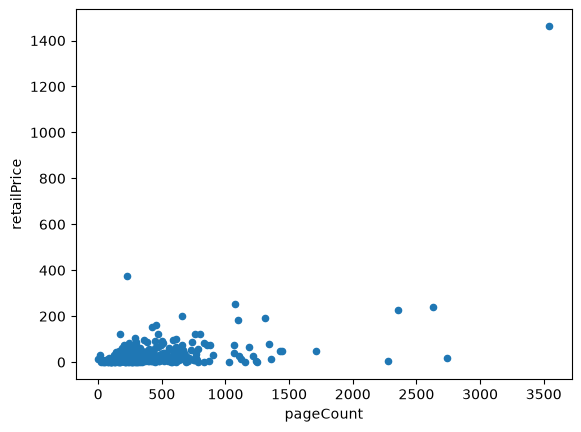

In [118]:
books = train_df.copy()
books.plot(kind = "scatter", x="pageCount", y="retailPrice")



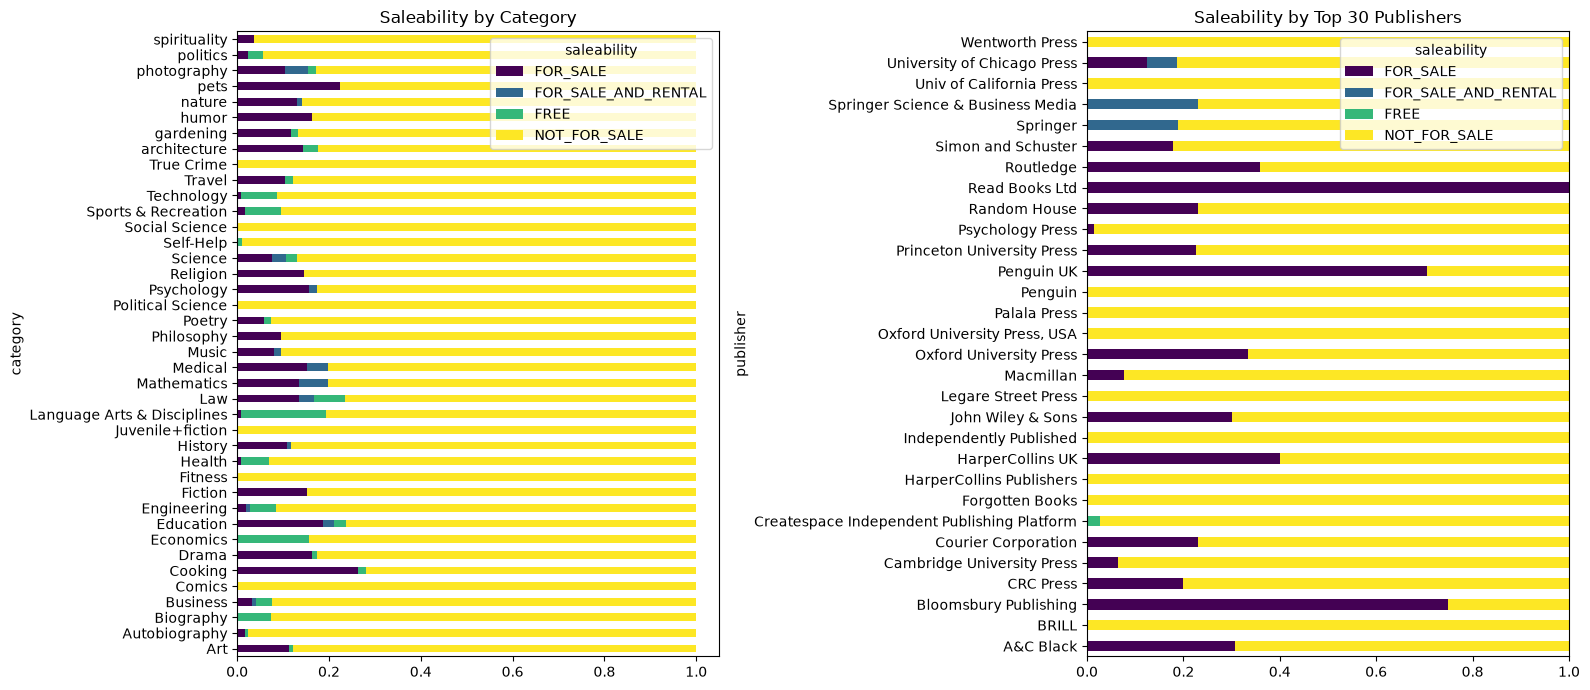

In [56]:
import seaborn as sns

top_publishers = books["publisher"].value_counts().iloc[:30].index
top_publishers_books = books[books["publisher"].isin(top_publishers)]

fig, axes = plt.subplots(1,2, figsize=(16, 7), sharey=False)
cat_maturity = pd.crosstab(books['category'], books['saleability'], normalize='index')
pub_maturity = pd.crosstab(top_publishers_books["publisher"], top_publishers_books['saleability'], normalize='index')

cat_maturity.plot(kind='barh', stacked=True, ax=axes[0], colormap='viridis')
axes[0].set_title("Saleability by Category")

pub_maturity.plot(kind='barh', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title("Saleability by Top 30 Publishers")

plt.tight_layout()
plt.show()

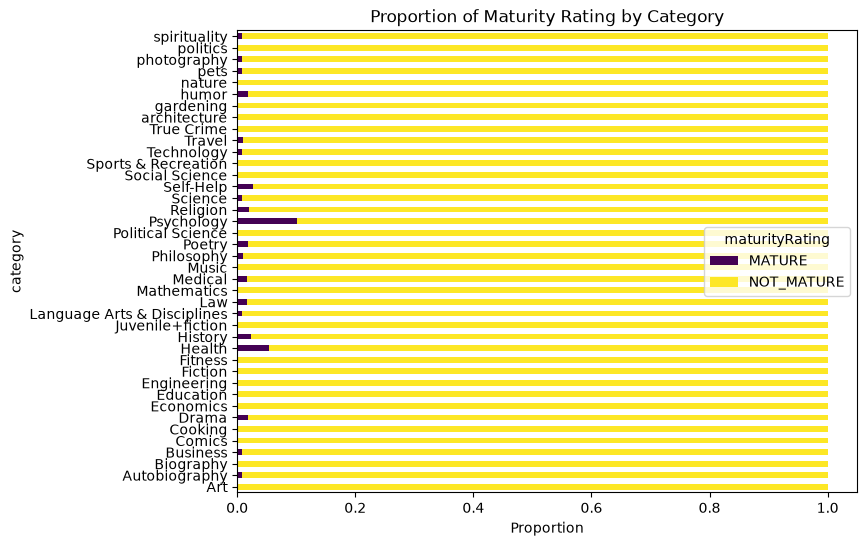

In [ ]:
import seaborn as sns

top_publishers = books["publisher"].value_counts().iloc(:20)


cat_maturity = pd.crosstab(books['category'], books['maturityRating'], normalize='index')

cat_maturity.plot(kind='barh', stacked=True, figsize=(8, 6), colormap='viridis')
plt.title("Proportion of Maturity Rating by Category")
plt.xlabel("Proportion")
plt.show()

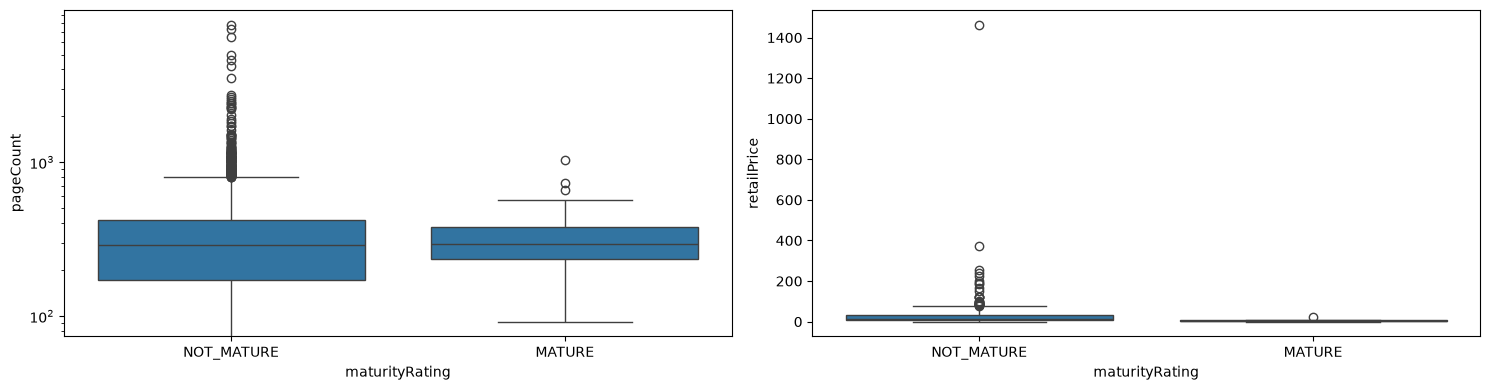

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.boxplot(data=books, x='maturityRating', y='pageCount', ax=axes[0])
sns.boxplot(data=books, x='maturityRating', y='retailPrice', ax=axes[1])

axes[0].set_yscale('log')
plt.tight_layout()
plt.show()

In [119]:
books_copy = train_df.copy()
books_copy.describe(include="all")

,kind,title,category,publishDate,publishYear,authorCount,pageCount,maturityRating,saleability,publisher,retailPrice,retailCurrency
count,4083,4083,4083,4063,4061.000000,4083.000000,4000.000000,4083,4083,2770,405.000000,405
unique,1,4083,40,1705,NaN,NaN,NaN,2,4,993,NaN,1
top,books#volume,The Law Times,Medical,2002,NaN,NaN,NaN,NOT_MATURE,NOT_FOR_SALE,Routledge,NaN,GBP
freq,4083,1,131,77,NaN,NaN,NaN,4037,3563,103,NaN,405
mean,NaN,NaN,NaN,NaN,1994.704506,1.267205,335.681250,NaN,NaN,NaN,31.275605,NaN
std,NaN,NaN,NaN,NaN,31.302290,0.712023,345.598193,NaN,NaN,NaN,81.105343,NaN
min,NaN,NaN,NaN,NaN,1757.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,NaN,1989.000000,1.000000,171.750000,NaN,NaN,NaN,6.990000,NaN
50%,NaN,NaN,NaN,NaN,2003.000000,1.000000,288.000000,NaN,NaN,NaN,14.990000,NaN
75%,NaN,NaN,NaN,NaN,2014.000000,1.000000,424.000000,NaN,NaN,NaN,33.190000,NaN


In [48]:

books_clean = (
    books_copy
    .drop(columns=["retailPrice", "retailCurrency", "publishDate", "kind"])
    .dropna(subset=[ "publishYear"])
)

books_clean.describe(include="all")


,title,category,publishYear,authorCount,pageCount,maturityRating,saleability,publisher
count,4061,4061,4061.000000,4061.000000,3984.00000,4061,4061,2764
unique,4061,40,NaN,NaN,NaN,2,4,989
top,The Law Times,Medical,NaN,NaN,NaN,NOT_MATURE,NOT_FOR_SALE,Routledge
freq,1,131,NaN,NaN,NaN,4015,3543,103
mean,NaN,NaN,1994.704506,1.269392,335.86496,NaN,NaN,NaN
std,NaN,NaN,31.302290,0.711497,345.53169,NaN,NaN,NaN
min,NaN,NaN,1757.000000,0.000000,0.00000,NaN,NaN,NaN
25%,NaN,NaN,1989.000000,1.000000,172.00000,NaN,NaN,NaN
50%,NaN,NaN,2003.000000,1.000000,288.00000,NaN,NaN,NaN
75%,NaN,NaN,2014.000000,1.000000,424.00000,NaN,NaN,NaN


In [120]:
books_cleaner = X_train.copy()
books_cleaner.describe(include="all")


,title,category,publishYear,authorCount,pageCount,maturityRating,publisher
count,4061,4061,4061.000000,4061.000000,3984.00000,4061,2764
unique,4061,40,NaN,NaN,NaN,2,989
top,The Law Times,Medical,NaN,NaN,NaN,NOT_MATURE,Routledge
freq,1,131,NaN,NaN,NaN,4015,103
mean,NaN,NaN,1994.704506,1.269392,335.86496,NaN,NaN
std,NaN,NaN,31.302290,0.711497,345.53169,NaN,NaN
min,NaN,NaN,1757.000000,0.000000,0.00000,NaN,NaN
25%,NaN,NaN,1989.000000,1.000000,172.00000,NaN,NaN
50%,NaN,NaN,2003.000000,1.000000,288.00000,NaN,NaN
75%,NaN,NaN,2014.000000,1.000000,424.00000,NaN,NaN


In [121]:
from sklearn.impute import SimpleImputer

books_num = books_cleaner[["publishYear","authorCount", "pageCount"]]
books_cat = books_cleaner.drop(columns=["title", "publishYear","authorCount", "pageCount"])
'''
mask = (~books_cat["publisher"].isin(top_publishers)) & (books_cat["publisher"].notna())
books_cat.loc[mask, "publisher"] = "Other"
books_cleaner.loc[mask, "publisher"] = "Other"
books_cleaner.head(20)
'''

'\nmask = (~books_cat["publisher"].isin(top_publishers)) & (books_cat["publisher"].notna())\nbooks_cat.loc[mask, "publisher"] = "Other"\nbooks_cleaner.loc[mask, "publisher"] = "Other"\nbooks_cleaner.head(20)\n'

In [131]:
for column in list(books_cleaner):
    print(books_cleaner[column].value_counts)

<bound method IndexOpsMixin.value_counts of 1950                                        The Law Times
1311                           Handbook of Burns Volume 1
2603           Catholicism, Protestantism, and Capitalism
3777                        Weaning and Human Development
3277                           The Music Lover's Handbook
                              ...                        
2256            Sprachwörterbücher im Nationalsozialismus
1046                    Introduction to Contact Mechanics
3069    Letters and Notes on the Manners, Customs, and...
649                      The Chemical History of a Candle
5769                                50 Spiritual Classics
Name: title, Length: 4061, dtype: str>
<bound method IndexOpsMixin.value_counts of 1950                            Law
1311                        Medical
2603                      Economics
3777                      Self-Help
3277                          Music
                   ...             
2256    Language Ar

In [127]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin

class TopPublishersEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, num):
        self.num = num
        self.top_pub = None

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            series = X.iloc[:, 0]
        else:
            series = pd.Series(X.ravel())
            
        self.top_pub = series.value_counts().iloc[:self.num].index.tolist()
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            X_copy = X.copy()
            col = X_copy.columns[0]
            mask = (~X_copy[col].isin(self.top_pub)) & (X_copy[col].notna())
            X_copy.loc[mask, col] = "Other"
            return X_copy
        else:
            series = pd.Series(X.ravel())
            mask = (~series.isin(self.top_pub)) & (series.notna())
            series.loc[mask] = "Other"
            return series.to_numpy().reshape(-1, 1)
    def get_feature_names_out(self, input_features=None):
        return input_features


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

pub_pipeline = Pipeline([
    ('mask', TopPublishersEncoder(num=20)),
    ('imputer', SimpleImputer(strategy="constant", fill_value="Unknown")),
    ('encoder', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, list(books_num)),
    ('pub', pub_pipeline, ["publisher"]),
    ('cat', OrdinalEncoder(), list(books_cat.drop(columns=["publisher"])))
], remainder='drop')

books_prepared = full_pipeline.fit_transform(books_cleaner)

In [128]:
books_prepared_df = pd.DataFrame(
    books_prepared,
    columns=full_pipeline.get_feature_names_out(),
    index=books_cleaner.index
)

# 2. Check the number of null values per column
print(books_prepared_df.isna().sum())
books_prepared_df.head(20)

num__publishYear       0
num__authorCount       0
num__pageCount         0
pub__publisher         0
cat__category          0
cat__maturityRating    0
dtype: int64


,num__publishYear,num__authorCount,num__pageCount,pub__publisher,cat__category,cat__maturityRating
1950,-2.322944,-1.784334,0.394562,20.0,16.0,1.0
1311,0.520649,3.838308,0.461762,17.0,18.0,1.0
2603,-1.268578,-0.378673,-0.277443,20.0,7.0,1.0
3777,-0.821271,-0.378673,-0.300817,20.0,26.0,0.0
3277,-0.501766,-0.378673,0.832826,8.0,19.0,1.0
5452,0.137243,1.026987,-0.195633,2.0,32.0,1.0
1758,-0.182262,1.026987,-0.370939,2.0,23.0,1.0
2153,0.744302,-0.378673,0.689660,8.0,8.0,1.0
222,0.776253,-0.378673,1.612936,12.0,21.0,1.0
1333,0.744302,2.432648,1.665527,6.0,18.0,1.0


In [129]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}


for name, model in models.items():
    scores = cross_val_score(model, books_prepared, y_train, scoring="accuracy", cv=5)
    print(f"{name:20} CV Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

Decision Tree        CV Accuracy: 0.8685 (+/- 0.0087)
Logistic Regression  CV Accuracy: 0.8880 (+/- 0.0013)
Extra Trees          CV Accuracy: 0.8976 (+/- 0.0072)
Random Forest        CV Accuracy: 0.8998 (+/- 0.0083)


In [130]:
def comparison_df(pred_labels, labels, rows):
    comparison_df = pd.DataFrame({
        "Actual": labels,
        "Predicted": pred_labels,
        "Correct":labels == pred_labels
    })
    return comparison_df.head(rows)


rf_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, random_state=42)
rf_clf.fit(books_prepared, y_train)
y_pred_rf = rf_clf.predict(books_prepared)

comparison_df(y_pred_rf, y_train, 60)

,Actual,Predicted,Correct
1950,NOT_FOR_SALE,NOT_FOR_SALE,True
1311,NOT_FOR_SALE,NOT_FOR_SALE,True
2603,NOT_FOR_SALE,NOT_FOR_SALE,True
3777,NOT_FOR_SALE,NOT_FOR_SALE,True
3277,NOT_FOR_SALE,NOT_FOR_SALE,True
5452,NOT_FOR_SALE,NOT_FOR_SALE,True
1758,NOT_FOR_SALE,NOT_FOR_SALE,True
2153,FOR_SALE,NOT_FOR_SALE,False
222,NOT_FOR_SALE,NOT_FOR_SALE,True
1333,FOR_SALE,NOT_FOR_SALE,False


In [104]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators': [100,300], 'max_features': np.linspace(0.2, 1.0, 4, dtype=float), 'max_depth': [None, 16, 32 ] },
    {'bootstrap': [False], 'n_estimators': [100,300], 'max_features': np.linspace(0.2, 1.0, 4, dtype=float)}
]

for_clf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(for_clf, param_grid, cv=5,
                           scoring='accuracy',
                           return_train_score=True)
grid_search.fit(books_prepared, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_depth': [None, 16, ...], 'max_features': array([0.2 ..., 1. ]), 'n_estimators': [100, 300]}, {'bootstrap': [False], 'max_features': array([0.2 ..., 1. ]), 'n_estimators': [100, 300]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,`

In [105]:
grid_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",16
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",np.float64(0.4666666666666667)
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0

In [109]:
feature_importances = grid_search.best_estimator_.feature_importances_
sorted(
    zip(feature_importances, full_pipeline.get_feature_names_out()),
    reverse=True
)

[(np.float64(0.4422062087417586), 'num__publishYear'),
 (np.float64(0.2104708631315399), 'num__pageCount'),
 (np.float64(0.17579237688867078), 'pub__publisher'),
 (np.float64(0.12878329066991556), 'cat__category'),
 (np.float64(0.03900818280108772), 'num__authorCount'),
 (np.float64(0.003739077767027382), 'cat__maturityRating')]

In [111]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

final_model = grid_search.best_estimator_

X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)

final_accuracy = accuracy_score(y_test, final_predictions)
print(f"Final Test Accuracy: {final_accuracy:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_predictions))

print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

Final Test Accuracy: 0.9095

Confusion Matrix:
[[ 32   0   0  60]
 [  0   5   0   4]
 [  0   0  29   0]
 [ 22   0   6 859]]

Classification Report:
                     precision    recall  f1-score   support

           FOR_SALE       0.59      0.35      0.44        92
FOR_SALE_AND_RENTAL       1.00      0.56      0.71         9
               FREE       0.83      1.00      0.91        29
       NOT_FOR_SALE       0.93      0.97      0.95       887

           accuracy                           0.91      1017
          macro avg       0.84      0.72      0.75      1017
       weighted avg       0.90      0.91      0.90      1017



In [112]:
from scipy import stats

correct_predictions = (final_predictions == y_test.values).astype(np.float64)

confidence = 0.95

accuracy_ci = stats.t.interval(
    confidence,
    len(correct_predictions) - 1,
    loc=correct_predictions.mean(),
    scale=stats.sem(correct_predictions)
)

print(f"Point Test Accuracy: {correct_predictions.mean():.4f}")
print(f"95% Confidence Interval: [{accuracy_ci[0]:.4f}, {accuracy_ci[1]:.4f}]")

Point Test Accuracy: 0.9095
95% Confidence Interval: [0.8919, 0.9272]
